# 1. Dependencies 

In [1]:
# import all libraries and functions here ...
import pandas as pd 
import os
import glob
import random 
import matplotlib.pyplot as plt

# 2. Exploratory Data Analysis 

In [2]:
# constants
#directories
DATA_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

#files
HORIZONTAL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__horizontal_well.csv"))
TYPEWELL_FILES = glob.glob(os.path.join(TRAIN_DIR + "/" + "*__typewell.csv"))

In [3]:
# code to see all files in the data/ input directory 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [4]:
# check horizontal csv file 
def get_horizontal_file():
    file_path = random.choice(HORIZONTAL_FILES)
    df = pd.read_csv(file_path)
    well_ID = os.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df, well_ID

In [5]:
# check typewell csv file 
def get_typewell_file():
    file_path = random.choice(TYPEWELL_FILES)
    df = pd.read_csv(file_path)
    well_ID = ps.path.basename(file_path).split("__")[0]
    df['WELL_ID'] = well_ID
    return df 

In [6]:
# get matching typewell file 
def get_matching_files():
    horizontal_df, well_ID  = get_horizontal_file()
    typewell_file = os.path.join(TRAIN_DIR + "/" + f"{well_ID}__typewell.csv")
    typewell_df = pd.read_csv(typewell_file)
    return horizontal_df, well_ID,typewell_df

In [7]:
h_df, ID , tw_df = get_matching_files()

In [8]:
h_df.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,12269.0,2950215.96,1015519.87,-10120.64,-10382.88,-10588.36,-10601.15,-10623.15,-10667.93,-10840.30,12162.28,108.372722,12162.28,46d24a09
1,12270.0,2950215.91,1015519.91,-10121.64,-10382.87,-10588.35,-10601.14,-10623.14,-10667.92,-10840.29,12163.28,110.526973,12163.28,46d24a09
2,12271.0,2950215.87,1015519.95,-10122.63,-10382.87,-10588.35,-10601.14,-10623.14,-10667.91,-10840.29,12164.29,120.907335,12164.29,46d24a09
3,12272.0,2950215.82,1015519.99,-10123.63,-10382.86,-10588.34,-10601.13,-10623.13,-10667.90,-10840.28,12165.29,113.037370,12165.29,46d24a09
4,12273.0,2950215.78,1015520.03,-10124.63,-10382.85,-10588.33,-10601.12,-10623.12,-10667.90,-10840.27,12166.30,108.390095,12166.30,46d24a09


In [9]:
tw_df.head()

,TVT,GR,Geology
0,12149.95,115.37,NaN
1,12150.45,115.76,NaN
2,12150.95,117.62,NaN
3,12151.45,125.04,NaN
4,12151.95,133.53,NaN


In [10]:
h_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6123 entries, 0 to 6122
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         6123 non-null   float64
 1   X          6123 non-null   float64
 2   Y          6123 non-null   float64
 3   Z          6123 non-null   float64
 4   ANCC       6123 non-null   float64
 5   ASTNU      6123 non-null   float64
 6   ASTNL      6123 non-null   float64
 7   EGFDU      6123 non-null   float64
 8   EGFDL      6123 non-null   float64
 9   BUDA       6123 non-null   float64
 10  TVT        6123 non-null   float64
 11  GR         4893 non-null   float64
 12  TVT_input  1674 non-null   float64
 13  WELL_ID    6123 non-null   object 
dtypes: float64(13), object(1)
memory usage: 669.8+ KB


In [11]:
h_df.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,6123.000000,6.123000e+03,6.123000e+03,6123.000000,6123.000000,6123.000000,6123.000000,6123.000000,6123.000000,6123.000000,6123.000000,4893.000000,1674.000000
mean,15330.000000,2.948928e+06,1.017966e+06,-10556.610188,-10259.124156,-10464.604156,-10477.394156,-10499.394156,-10544.170070,-10716.544156,12722.004717,82.457654,12627.624158
std,1767.702181,8.113515e+02,1.544272e+03,102.976933,89.369207,89.369207,89.369207,89.369207,89.369186,89.369207,106.362946,16.586393,169.927328
min,12269.000000,2.947526e+06,1.015520e+06,-10689.810000,-10382.880000,-10588.360000,-10601.150000,-10623.150000,-10667.930000,-10840.300000,12162.280000,38.246641,12162.280000
25%,13799.500000,2.948217e+06,1.016606e+06,-10647.790000,-10344.840000,-10550.320000,-10563.110000,-10585.110000,-10629.890000,-10802.260000,12746.795000,69.813367,12540.947500
50%,15330.000000,2.948924e+06,1.017952e+06,-10570.220000,-10271.060000,-10476.540000,-10489.330000,-10511.330000,-10556.100000,-10728.480000,12753.020000,81.661747,12735.185000
75%,16860.500000,2.949645e+06,1.019303e+06,-10476.855000,-10164.655000,-10370.135000,-10382.925000,-10404.925000,-10449.705000,-10622.075000,12758.305000,94.500388,12749.500000
max,18391.000000,2.950216e+06,1.020664e+06,-10120.640000,-10113.790000,-10319.270000,-10332.060000,-10354.060000,-10398.840000,-10571.210000,12779.660000,175.719124,12756.590000


In [12]:
tw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665 entries, 0 to 1664
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      1665 non-null   float64
 1   GR       1665 non-null   float64
 2   Geology  1115 non-null   object 
dtypes: float64(2), object(1)
memory usage: 39.2+ KB


In [13]:
tw_df['Geology']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
1660    BUDA
1661    BUDA
1662    BUDA
1663    BUDA
1664    BUDA
Name: Geology, Length: 1665, dtype: object

In [14]:
# another well 
h_df_1, _, tw_df_1 = get_matching_files()

In [15]:
h_df_1.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELL_ID
0,10322.0,2958137.26,1081095.68,-8093.11,-8436.60,-8580.40,-8659.80,-8758.14,-8796.89,-8906.80,10222.76,134.471453,10222.76,684a6fc1
1,10323.0,2958137.24,1081095.70,-8094.11,-8436.57,-8580.37,-8659.77,-8758.12,-8796.87,-8906.77,10223.79,129.943463,10223.79,684a6fc1
2,10324.0,2958137.22,1081095.73,-8095.11,-8436.55,-8580.35,-8659.75,-8758.09,-8796.84,-8906.75,10224.81,138.822260,10224.81,684a6fc1
3,10325.0,2958137.20,1081095.75,-8096.11,-8436.53,-8580.33,-8659.73,-8758.07,-8796.82,-8906.73,10225.83,135.426268,10225.83,684a6fc1
4,10326.0,2958137.19,1081095.78,-8097.11,-8436.50,-8580.30,-8659.70,-8758.05,-8796.80,-8906.70,10226.85,129.313482,10226.85,684a6fc1


In [16]:
h_df_1.shape

(11449, 14)

In [17]:
h_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11449 entries, 0 to 11448
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         11449 non-null  float64
 1   X          11449 non-null  float64
 2   Y          11449 non-null  float64
 3   Z          11449 non-null  float64
 4   ANCC       11449 non-null  float64
 5   ASTNU      11449 non-null  float64
 6   ASTNL      11449 non-null  float64
 7   EGFDU      11449 non-null  float64
 8   EGFDL      11449 non-null  float64
 9   BUDA       11449 non-null  float64
 10  TVT        11449 non-null  float64
 11  GR         5786 non-null   float64
 12  TVT_input  1631 non-null   float64
 13  WELL_ID    11449 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.2+ MB


In [18]:
tw_df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3705 entries, 0 to 3704
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TVT      3705 non-null   float64
 1   GR       3705 non-null   float64
 2   Geology  2281 non-null   object 
dtypes: float64(2), object(1)
memory usage: 87.0+ KB


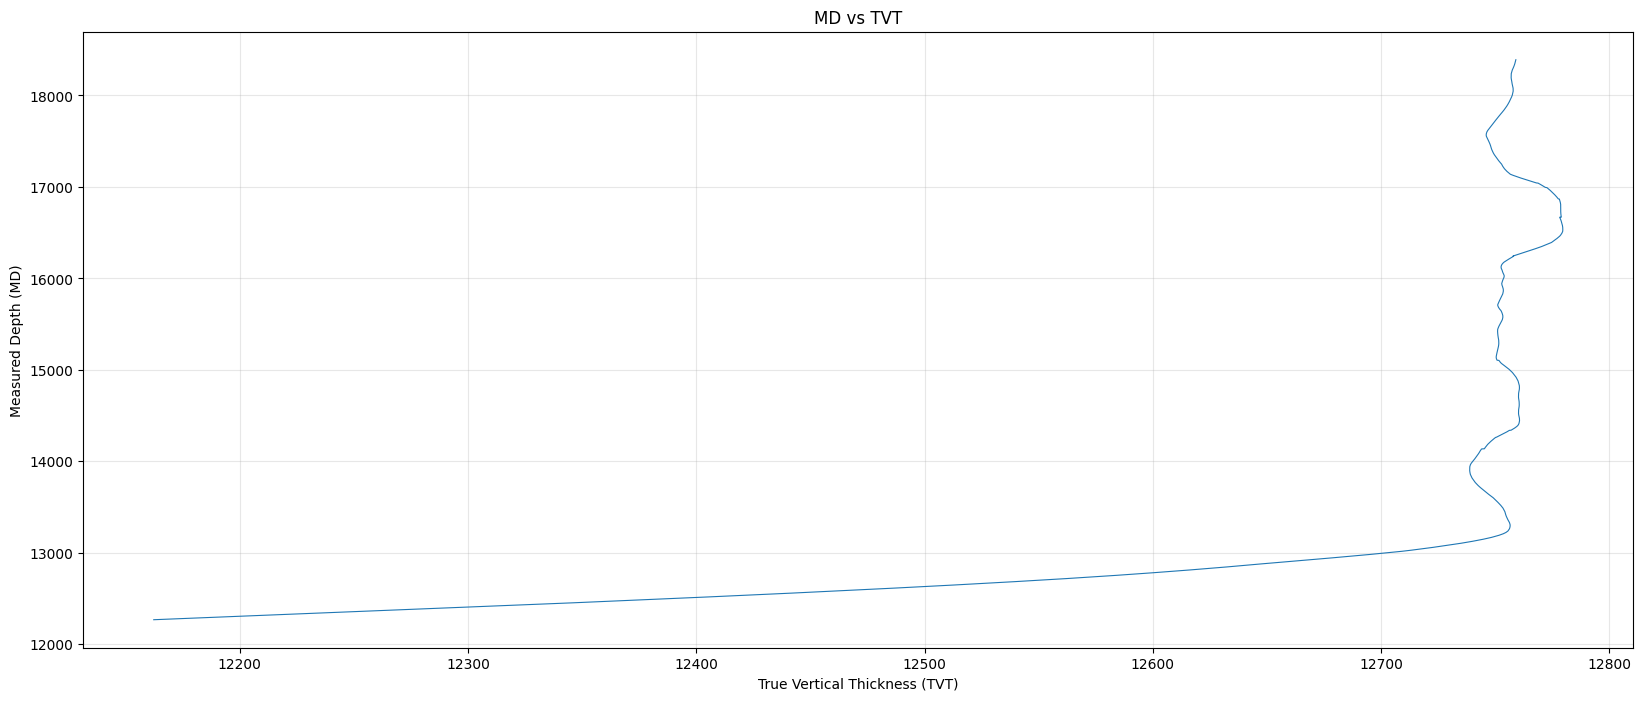

In [19]:
# MD against TVT 
# illustrates where the horizontal drilling starts (?)
plt.figure(figsize = (20,8))
plt.plot(h_df['TVT'], h_df['MD'], linewidth = 0.8)
plt.xlabel("True Vertical Thickness (TVT)")
plt.ylabel("Measured Depth (MD)")
plt.title("MD vs TVT")
plt.grid(True, alpha = 0.3)
plt.show()

# 3. Data Cleaning 

# 4. Feature Engineering

# 5. Modeling

# 6. Evaluation